# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [1]:
from imports import *
from vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [2]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [3]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

  0%|          | 0/10000 [00:00<?, ?it/s]

  4%|▎         | 350/10000 [00:00<00:02, 3492.42it/s]

  7%|▋         | 709/10000 [00:00<00:02, 3548.03it/s]

 11%|█         | 1073/10000 [00:00<00:02, 3587.41it/s]

 14%|█▍        | 1446/10000 [00:00<00:02, 3642.08it/s]

...

 73%|███████▎  | 7309/10000 [00:01<00:00, 4029.34it/s]

 77%|███████▋  | 7713/10000 [00:02<00:00, 4021.10it/s]

 78%|███████▊  | 7767/10000 [00:02<00:00, 3832.87it/s]

steps:  7768
conclusion:  1.0
conclusion core 1.0


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.772547,0.066766,0.018956,0.238746,0.515502,0.344601,0.462970,0.026504,0.330183,0.297280,...,0.154959,0.019747,0.501432,0.347118,0.687508,0.106320,0.727395,0.674796,0.938992,0.970215
1,0.765442,0.069302,0.019408,0.246091,0.517500,0.339201,0.464959,0.025691,0.324897,0.292291,...,0.164623,0.019747,0.515427,0.347118,0.682329,0.104061,0.724211,0.680041,0.937603,0.972655
2,0.766875,0.074092,0.018661,0.244610,0.537437,0.325007,0.464959,0.026298,0.331955,0.284086,...,0.170198,0.018987,0.523415,0.365463,0.696037,0.102579,0.730556,0.676549,0.934245,0.972010


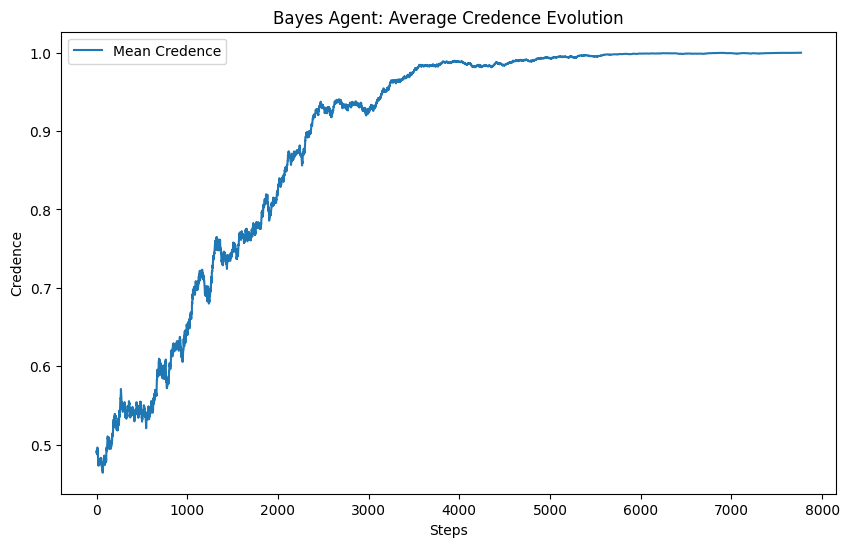

In [4]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [5]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [6]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

  0%|          | 0/10000 [00:00<?, ?it/s]

  4%|▍         | 380/10000 [00:00<00:02, 3788.40it/s]

  8%|▊         | 761/10000 [00:00<00:02, 3790.08it/s]

 11%|█▏        | 1148/10000 [00:00<00:02, 3825.38it/s]

 15%|█▌        | 1531/10000 [00:00<00:02, 3627.94it/s]

...

 97%|█████████▋| 9730/10000 [00:04<00:00, 2194.66it/s]

100%|█████████▉| 9951/10000 [00:04<00:00, 2165.77it/s]

100%|██████████| 10000/10000 [00:04<00:00, 2357.81it/s]

steps:  10000
conclusion:  0.91


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,"[0.49765195866414064, 0.2609210063145413]","[0.2769221964908806, 0.9429039918661676]","[0.8879135538718318, 0.1529112616601996]","[0.36466413167927786, 0.09968378514717681]","[2.637018796558584e-10, 0.1524570533037269]","[0.1423198990407924, 0.20568180138210818]","[0.42152464455146144, 0.9999999997102106]","[0.1447371033155604, 0.4587554937574764]","[0.20703851045439192, 0.345376108374621]","[0.2983931909809965, 0.3944834623835242]",...,"[0.7385236930596663, 0.2625461141928022]","[0.9384140896893226, 0.48097241491258164]","[0.7230413014656601, 0.5010899612650679]","[0.000402879525823386, 0.9795382714046599]","[0.8174123084865214, 0.03633677516167177]","[0.1284805063176604, 0.21655842536781758]","[0.2942688493867938, 0.6083248400796029]","[0.20255803131249572, 0.0021493369390458332]","[0.39599930652951554, 0.2478561669073985]","[0.5734153669738578, 0.46166335611040044]"
1,"[0.5915323823022781, 0.5622406458749947]","[0.4904132872928367, 0.5233177410852613]","[0.4402521887766574, 0.4777829261888069]","[0.5074863019116734, 0.4765900128317529]","[0.5045663199660452, 0.4501632674756666]","[0.4258667648326509, 0.5062211098132162]","[0.5022981479185761, 0.5846983110386065]","[0.5236288077727789, 0.38142122287384633]","[0.5286324757331857, 0.48670357707314893]","[0.4635967251770064, 0.47337707835905174]",...,"[0.420291201331676, 0.33534023407707364]","[0.41844074440721574, 0.5395188481788931]","[0.4990539273584691, 0.39230787775675724]","[0.44681407557340014, 0.5244174184544087]","[0.4667572729336589, 0.5751662264419556]","[0.49643032522339514, 0.48860302001018713]","[0.324255327482653, 0.5207850849400011]","[0.5741225766436187, 0.4226241166306645]","[0.4587015177591552, 0.48125514174634154]","[0.4802967109708638, 0.3978347633997304]"
2,"[0.5537712132079378, 0.5046970434415873]","[0.5007208201697892, 0.49108459854324144]","[0.4456858614174106, 0.4842539894935369]","[0.37973513062007586, 0.526795547989991]","[0.4403823986721737, 0.5094634597451536]","[0.48323801840512876, 0.517843959103221]","[0.48958395684341455, 0.4936385546830653]","[0.5243158649152823, 0.42177062640151486]","[0.44065686154364486, 0.472452686932498]","[0.459124908808839, 0.5352745030802305]",...,"[0.4460210938297867, 0.4041597305295852]","[0.49347119421805535, 0.4742096155626536]","[0.4595453503472592, 0.5047716413820897]","[0.44464406803052686, 0.43902617021126256]","[0.4745386172332885, 0.48982887324515206]","[0.451004046979446, 0.4930602586942739]","[0.4858054908433117, 0.5070949489704917]","[0.5536714346800388, 0.47748335150950355]","[0.4434917959656368, 0.467319535422497]","[0.48193231392990915, 0.4876530129273603]"


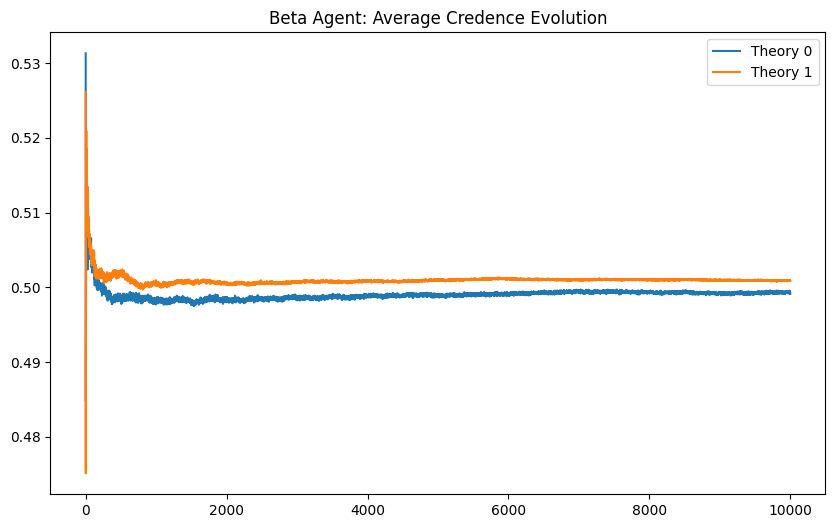

In [7]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

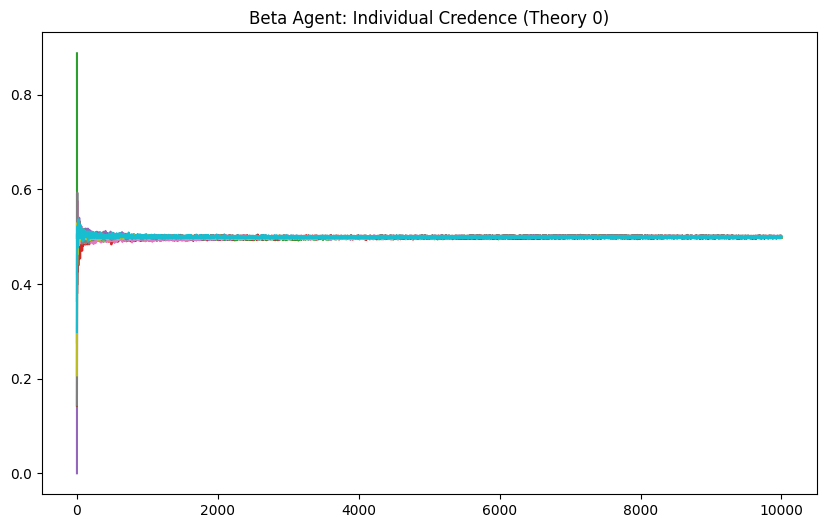

In [8]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()